# Прогнозирование продаж в магазинах офлаин-ритейлера в США <a class="tocSkip">

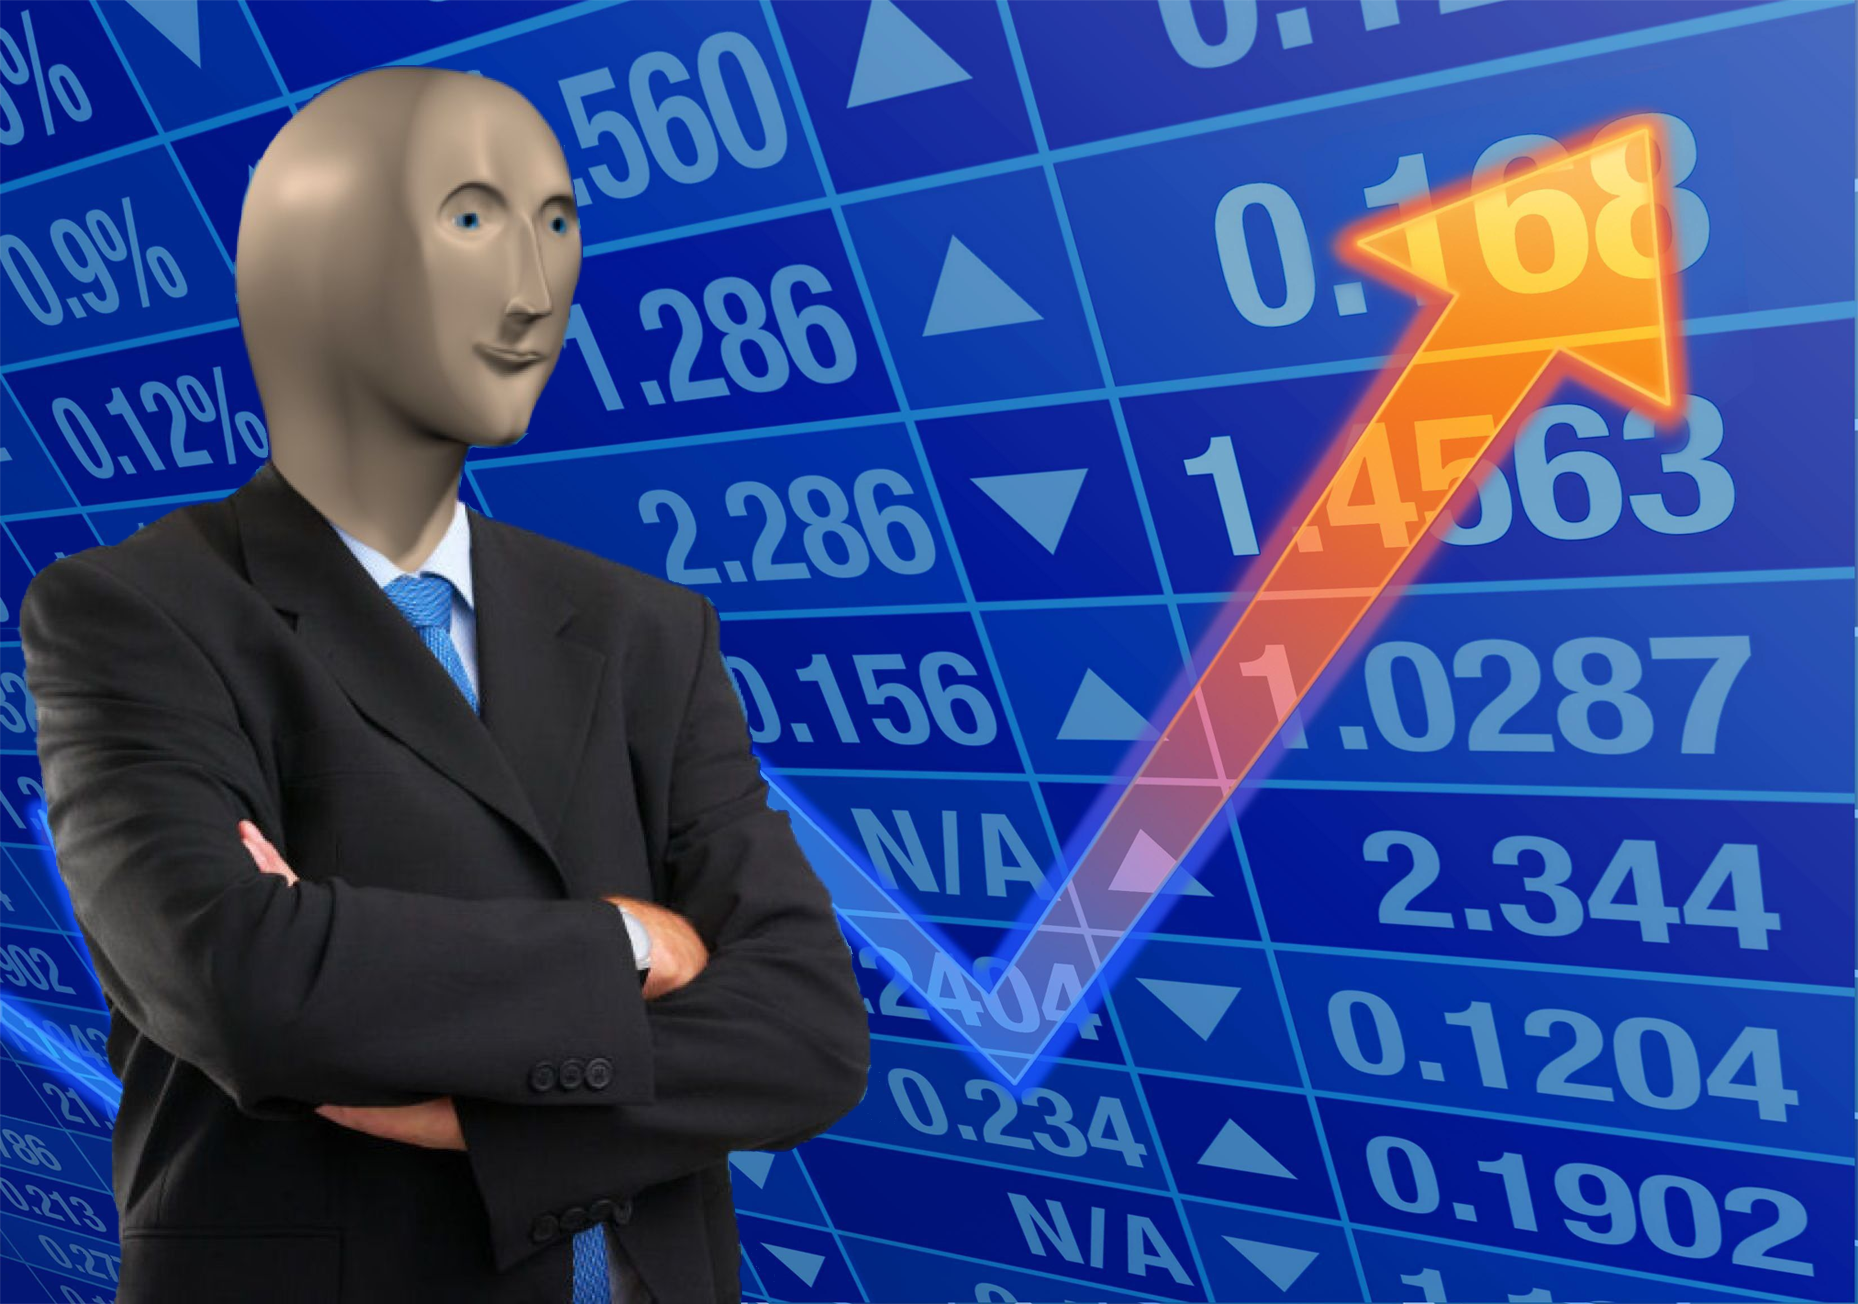

В качестве экзаменационного задания вам предстоит построить модель прогнозирования спроса(продаж) на товары в магазинах офлаин-ритейлера в США . Всего в датасете 3 магазина, в каждом магазине по 15 артикулов (товаров). Вам нужно выбрать 1 магазин (любой из 3).

Прогнозировать продажи нужно на неделю, на месяц и на квартал. Пользоваться сторонними библиотеками с соответствующими реализациями моделей можно.

В качестве дополнительной информации вам переданы данные о цене товара (меняются раз в неделю, а также о праздниках в США).

**Практическое задание 1 - срок к 10.12. Прогнозирование с помощью классических методов.**


**1.1 Реализовать класс для обучения и оценки качества прогноза на неделю, на месяц и на квартал с помощью классических методов:**

1) Должен предобрабатывать исходные данные в удобный формат; 

2) Должен обучаться для задачи прогнозирования; 

3) В качестве моделей должны использоваться классические модели, которые изучали в лекциях 2-5.

4) Должен оценивать качество своих прогнозов;

5) Код должен быть написан по PEP-8;


**1.2 Подготовить отчет в виде jupyter ноутбука:**

1) Все методы должны быть реализованы в классе, в ноутбуке только вызов методов, визуализация и комментарии;

2) Для прогнозов использованы как минимум 3 любые классические модели, которые изучали в лекциях 2-5 

3) Отчет содержит текстовое описание реализованного класса и основных методов, продемонстрирован результат работы этих методов.

4) Отчет содержит визуализации результатов прогнозов и оценки метрик качества на неделю, на месяц и на квартал

5) Отчет содержит текстовые ответы на следующие вопросы:

 * Какие методы предобработки данных вы использовали? Почему пробовали именно их?

 * Какие модели пробовали? Почему пробовали именно их?

 * Как вы проверяете качество модели? На каких данных? Какие метрики используюте? Чем обусловлен выбор именно этих метрик?
 
 * Какая подход из испробованных самый оптимальный с точки зрения качества прогнозирования?

 * Какое итоговое качество модели на тестовом датасете?
 

**Практическое задание 2 - срок к 17.12. Прогнозирование с помощью современных методов.**

**2.1 Реализовать класс для обучения и оценки качества прогноза на неделю, на месяц и на квартал с помощью современных методов:**

**2.2 Подготовить отчет в виде jupyter ноутбука:**


Подпункты 2.1 и 2.2 повторяют полностью подпункты 1.1 и 1.2, кроме единственного исключения - в качестве модели достаточно попробовать только одну - либо градиентный бустинг, либо нейронную сеть, либо обе (по желанию).

**Итоговый проект - срок к 24.12. Реализовать итоговый класс, в котором выбрана 1-2 лучшие по вашему мнению модели, который умеет:** 

1) предобрабатывать исходные данные в удобный формат; 

2) обучаться для задачи прогнозирования; 

3) оценивать качество своих прогнозов;

4) сохранять модели и подгружать их; 

5) Прогнозировать продажи на неделю, на месяц и на квартал.

Должна быть рабочая программа, которая делает инференс (прогнозирование на произвольном тестовом датасете (аналогично тому, который есть у вас)) без обучения (предобученные модели сохранены в файлы и подгружаются в тексте класса)

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import statsmodels.api as sm
from scipy import stats
import plotly.express as px
from statsmodels.tsa.stattools import adfuller, kpss

In [2]:
#основные данные
sales = pd.read_csv('data/shop_sales.csv')
sales.head()

,item_id,store_id,date_id,cnt
0,STORE_2_085,STORE_2,1,3
1,STORE_2_085,STORE_2,2,8
2,STORE_2_085,STORE_2,3,0
3,STORE_2_085,STORE_2,4,3
4,STORE_2_085,STORE_2,5,0


In [3]:
#данные о датах и праздниках (соединяется с продажами по полю date_id)
calendar = pd.read_csv('data/shop_sales_dates.csv')
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,date_id,CASHBACK_STORE_1,CASHBACK_STORE_2,CASHBACK_STORE_3
0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,1,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,NaN,NaN,NaN,NaN,2,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,NaN,NaN,NaN,NaN,3,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,NaN,NaN,NaN,NaN,4,0,1,1
4,2011-02-02,11101,Wednesday,5,2,2011,NaN,NaN,NaN,NaN,5,1,1,0


In [4]:
#данные о датах и праздниках (соединяется с датами по полю wm_yr_wk)
prices = pd.read_csv('data/shop_sales_prices.csv')
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,STORE_2,STORE_2_085,11101,1.00
1,STORE_2,STORE_2_043,11101,2.88
2,STORE_2,STORE_2_054,11101,2.28
3,STORE_2,STORE_2_090,11101,1.25
4,STORE_2,STORE_2_252,11101,1.48


Графики продаж артикулов по магазинам:

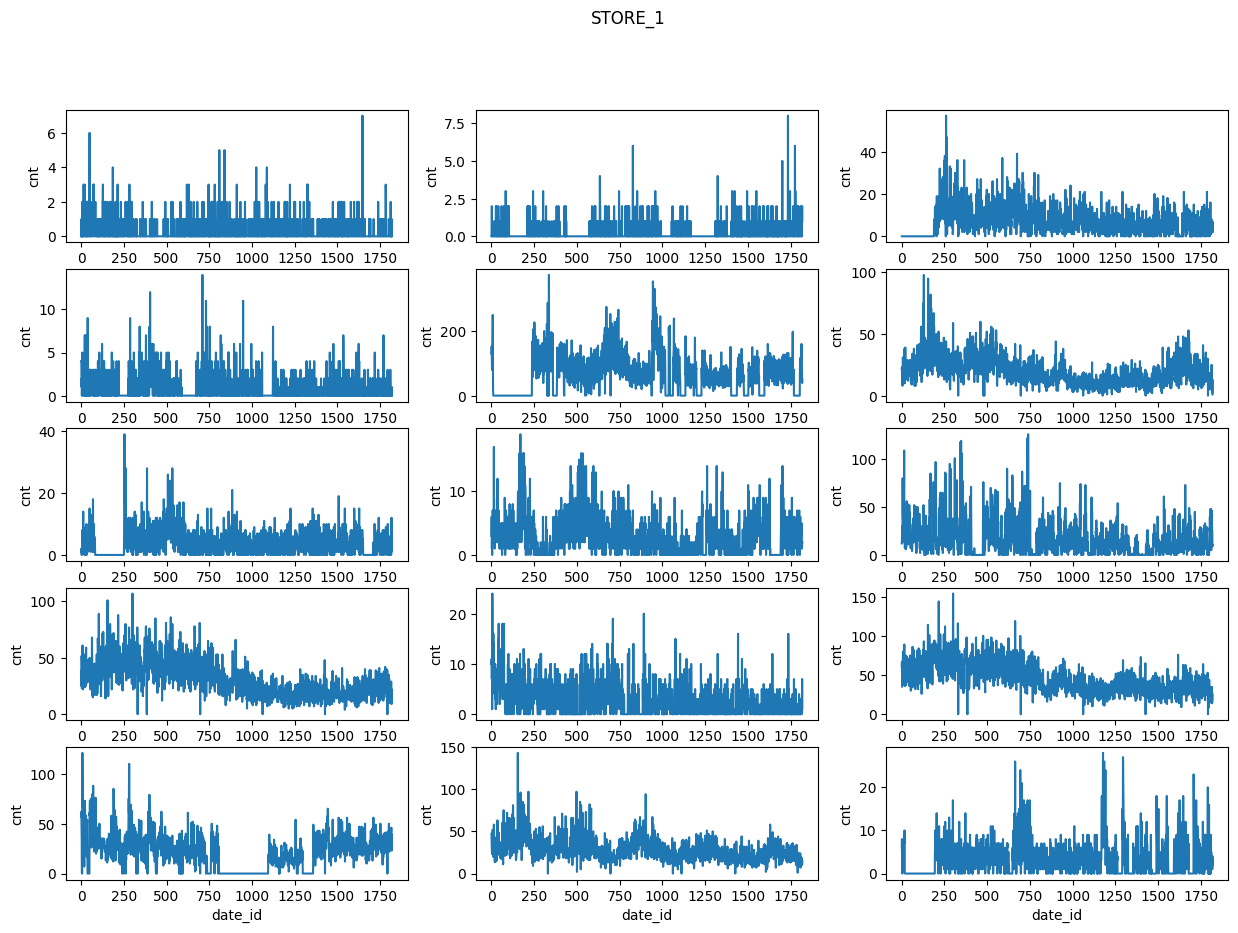

In [5]:
fig,ax = plt.subplots(5,3,figsize=(15,10))

for i, art in enumerate(sales[sales.store_id=='STORE_1'].item_id.unique()):
    sns.lineplot(data = sales[(sales.item_id==art) & (sales.store_id=='STORE_1')],
                 x='date_id',y='cnt',ax = ax[i//3][i%3])
plt.suptitle("STORE_1");

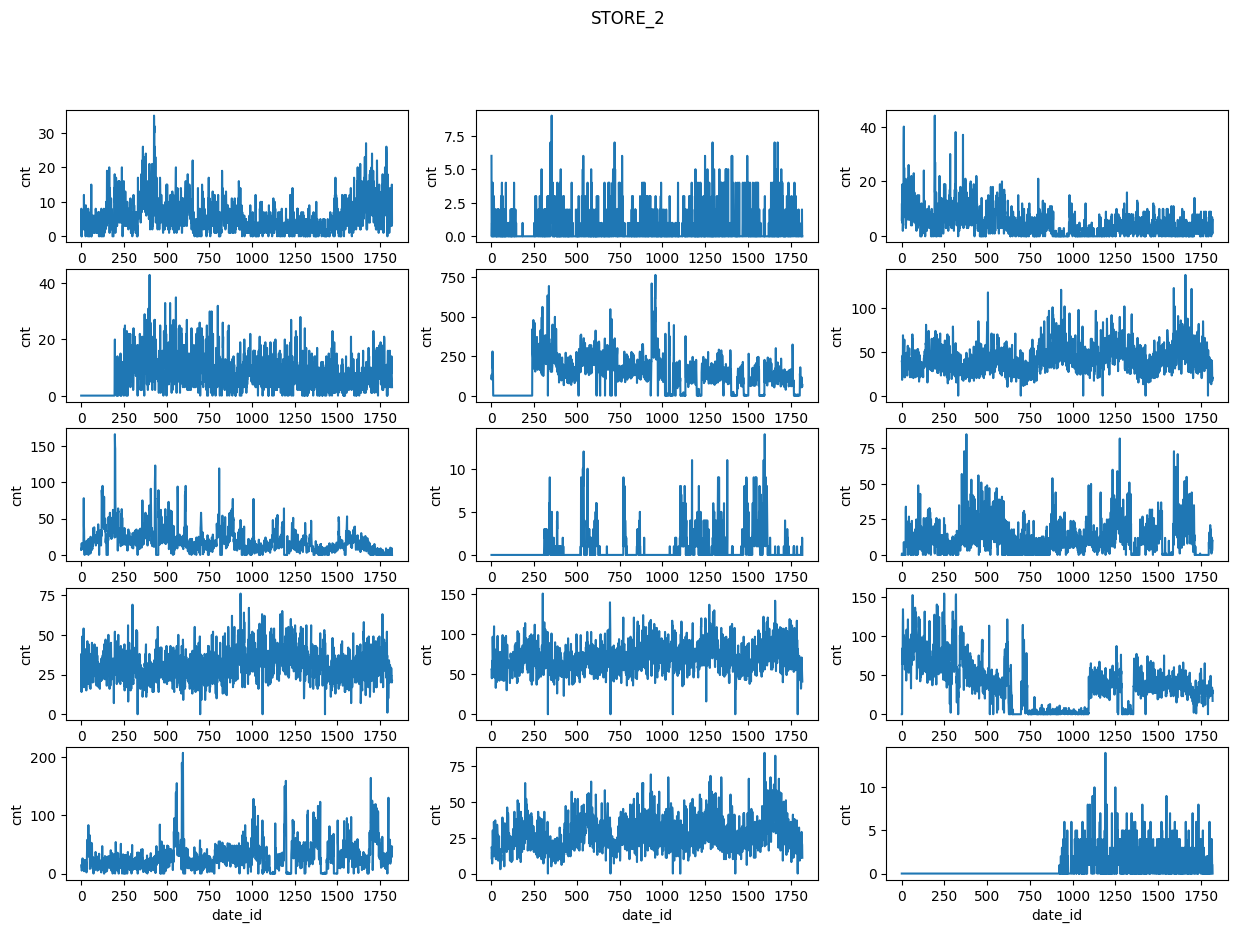

In [6]:
fig,ax = plt.subplots(5,3,figsize=(15,10))

for i, art in enumerate(sales[sales.store_id=='STORE_2'].item_id.unique()):
    sns.lineplot(data = sales[(sales.item_id==art) & (sales.store_id=='STORE_2')],
                 x='date_id',y='cnt',ax = ax[i//3][i%3])
plt.suptitle("STORE_2");

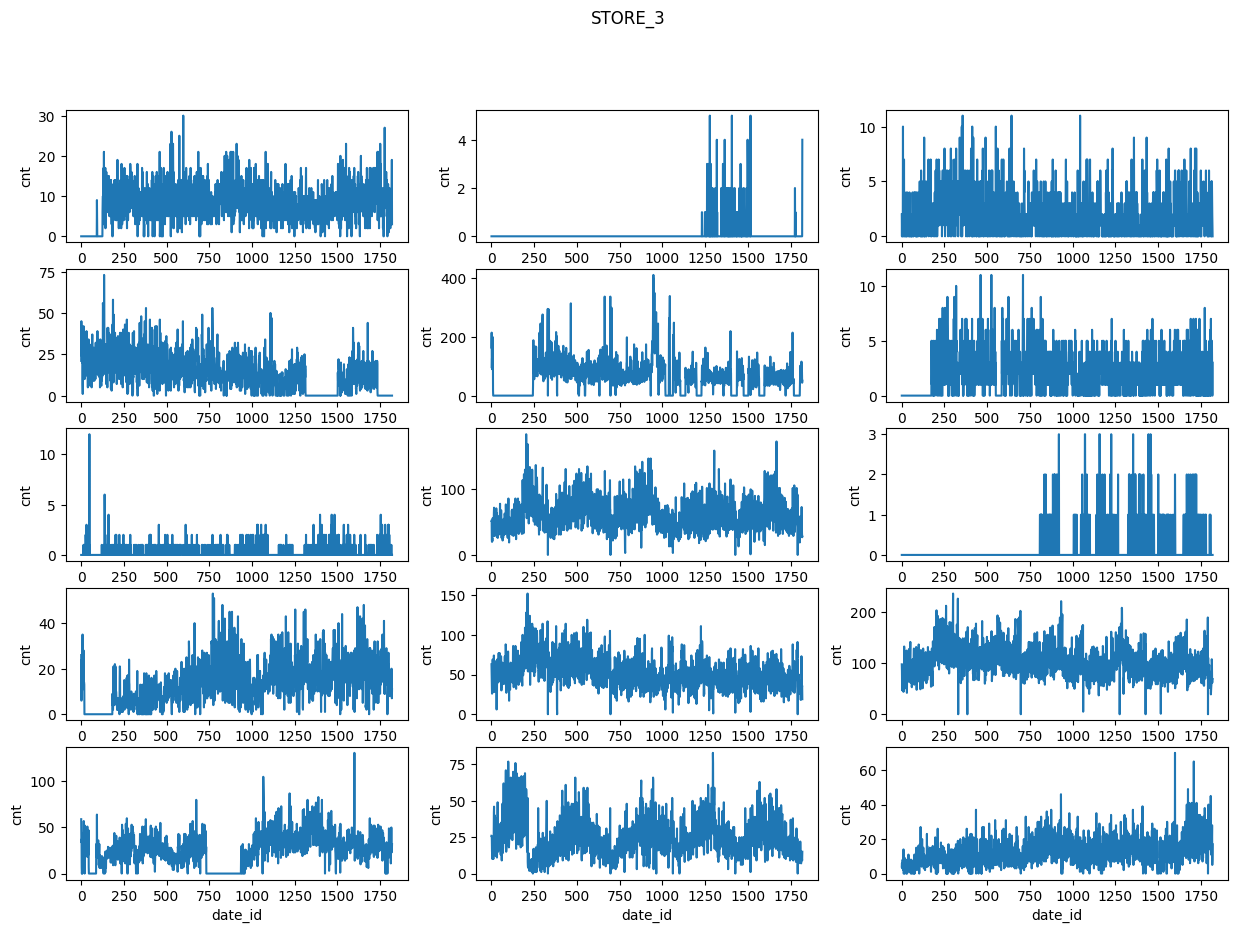

In [7]:
fig,ax = plt.subplots(5,3,figsize=(15,10))

for i, art in enumerate(sales[sales.store_id=='STORE_3'].item_id.unique()):
    sns.lineplot(data = sales[(sales.item_id==art) & (sales.store_id=='STORE_3')],
                 x='date_id',y='cnt',ax = ax[i//3][i%3]);

plt.suptitle("STORE_3");

In [8]:
STORE_ID: str = "STORE_2"

In [9]:
# store_sales = sales[sales["store_id"] == STORE_ID]
# store_prices = prices[prices["store_id"] == STORE_ID]


In [10]:
# store_sales.head()

In [11]:
# store_prices.head()

In [12]:
# data = store_sales \
#     .merge(calendar, on="date_id", how="left", suffixes=("", "x")) \
#     .merge(store_prices, on=["store_id", "item_id", "wm_yr_wk"], how="left", suffixes=("", "y"))
# data.sort_values(by="date_id", inplace=True)
# # data.set_index("date_id", inplace=True)
# data.head(10)

In [13]:
# drop_columns = ["date_id", "wm_yr_wk", "store_id", "event_name_1", "event_type_1", "event_name_2", "event_type_2", "weekday"]
# data.drop(columns=drop_columns, inplace=True)

In [14]:
# assert len(data) == len(store_sales)

In [15]:
from etna.datasets.tsdataset import TSDataset
from etna import (
    analysis,
    models,
    transforms,
    metrics
)
from etna.pipeline import Pipeline

In [16]:
# data.rename(columns={"item_id": "segment", "date": "timestamp", "cnt": "target"}, inplace=True)
# # data.drop(columns=["date_id"], inplace=True)
# # data = data[["timestamp", "segment", "target"]]
# df_main = TSDataset.to_dataset(data[["timestamp", "segment", "target"]])  # Основной временной ряд
# df_exog = TSDataset.to_dataset(data.drop(columns=["target"]))
# ts_data = TSDataset(df=df_main, freq="D", df_exog=df_exog)
# # ts_data = TSDataset(df=data[["timestamp", "segment", "target"]], df_exog=data.drop(columns=["target"]), known_future=["weekday"], freq="D")
# # ts_data = TSDataset(data, freq="D")
# ts_data.head()

In [17]:
# ts_data.plot()

In [18]:
# ts_data.describe()

In [19]:
# ts_data.head()

In [20]:
# data.info()

In [21]:
# analysis.acf_plot(ts_data, lags=365)

In [22]:
# anomaly_dict = analysis.get_anomalies_iqr(ts_data, trend=True, seasonality=True, window_size=365)
# analysis.plot_anomalies(ts_data, anomaly_dict)

In [23]:
# train_ts, test_ts = ts_data.train_test_split(test_size=7)

In [24]:
# test_ts.head()

In [25]:
from forecaster import Forecaster


model = Forecaster(model_name="MA", horizon=90, sales_data=sales, prices_data=prices, calendar_data=calendar, store_id=STORE_ID)
model.preprocess_data()

In [26]:
model.fit()

In [27]:
model.eval()

,RMSE,MAE,SMAPE
STORE_2_043,1.148116,1.040860,149.035168
STORE_2_054,2.854639,2.230341,81.618052
STORE_2_085,5.465892,4.565357,55.001980
STORE_2_090,80.515215,66.234559,95.886507
STORE_2_252,18.618606,15.568267,38.446922
STORE_2_325,5.346696,4.130321,53.414015
STORE_2_376,6.257274,5.642462,128.182986
STORE_2_391,0.518154,0.308031,194.109416
STORE_2_524,12.719083,11.944910,163.594450
STORE_2_555,9.013882,6.755564,23.204184
